In [1]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
hh_df, hh_meta = pyreadstat.read_sav('1_CFSVA18_DB_HouseholdQues_Full_Annex_201904_NISR.sav')
cm_df, cm_meta = pyreadstat.read_sav('2_CFSVA18_DB_ChildAndMother_Full_Annex_201904_NISR.sav')
vl_df, vl_meta = pyreadstat.read_sav('3_CFSVA18_DB_VillageQues_Full_Annex_201904_NISR.sav')

In [3]:
hh_df.head()           
hh_df.iloc[:5, :10]   

,VHHSize,VSampleSize,TotDistHHs,FinalWeight,PARENT_KEY,LYR01,All_Sample,UrbanRural,S0_C_Prov,S0_D_Dist
0,83.0,10.0,1524.181693,152.418169,uuid:674f7c8d-fec0-4da3-a4f5-556e41825b6e,,1.0,2.0,3.0,301.0
1,140.0,10.0,2235.658173,223.565817,uuid:6d4dbca4-9a73-4029-be2f-699c2d65db8c,,1.0,2.0,4.0,401.0
2,125.0,10.0,4180.021836,418.002184,uuid:205acfc7-6e51-4c47-8524-31945bc91745,,1.0,2.0,4.0,405.0
3,149.0,10.0,4224.365403,422.436540,uuid:22b2a07b-fdc1-4df5-8d42-b0b1018e18e1,,1.0,2.0,4.0,405.0
4,149.0,10.0,2625.957395,262.595739,uuid:e2b83c40-91b7-4227-935a-4bce62e5e59f,,1.0,1.0,4.0,405.0


In [4]:
print(hh_df.dtypes.value_counts())
print("\n")
print(cm_df.dtypes.value_counts())
print("\n")
print(vl_df.dtypes.value_counts())

float64    322
object      21
Name: count, dtype: int64


float64           211
object              6
datetime64[ns]      2
Name: count, dtype: int64


float64    162
object       1
Name: count, dtype: int64


In [5]:
def inspect(df, name):
    print(f"\n{name} SHAPE:", df.shape)
    print(f"\n{name} INFO:")
    print(df.info())
    print(f"\n{name} HEAD:")
    print(df.head())

inspect(hh_df, "Household")
inspect(cm_df, "Child & Mother")
inspect(vl_df, "Village")


Household SHAPE: (9709, 343)

Household INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9709 entries, 0 to 9708
Columns: 343 entries, VHHSize to FS_final_lyr_2CAT
dtypes: float64(322), object(21)
memory usage: 25.4+ MB
None

Household HEAD:
   VHHSize  VSampleSize   TotDistHHs  FinalWeight  \
0     83.0         10.0  1524.181693   152.418169   
1    140.0         10.0  2235.658173   223.565817   
2    125.0         10.0  4180.021836   418.002184   
3    149.0         10.0  4224.365403   422.436540   
4    149.0         10.0  2625.957395   262.595739   

                                  PARENT_KEY LYR01  All_Sample  UrbanRural  \
0  uuid:674f7c8d-fec0-4da3-a4f5-556e41825b6e               1.0         2.0   
1  uuid:6d4dbca4-9a73-4029-be2f-699c2d65db8c               1.0         2.0   
2  uuid:205acfc7-6e51-4c47-8524-31945bc91745               1.0         2.0   
3  uuid:22b2a07b-fdc1-4df5-8d42-b0b1018e18e1               1.0         2.0   
4  uuid:e2b83c40-91b7-4227-935a-4bce62e5e

In [6]:
def clean_columns(df):
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
    return df

hh_df = clean_columns(hh_df)
cm_df = clean_columns(cm_df)
vl_df = clean_columns(vl_df)

In [7]:
def missing_report(df):
    return df.isnull().mean().sort_values(ascending=False)

print(missing_report(hh_df).head(10))
print(missing_report(cm_df).head(10))
print(missing_report(vl_df).head(10))

s4n3         1.000000
as12_07_3    0.999897
ds12_07_3    0.999794
ds12_04_3    0.999691
bs12_07_3    0.999279
hs12_07_3    0.999176
ms12_07_3    0.998764
cs12_04_3    0.997734
cs12_07_3    0.997528
as12_04_3    0.997013
dtype: float64
s13_03_3         1.000000
spliter_two      1.000000
separator_two    1.000000
cs14_15_2        0.994210
gs14_15_2        0.989905
mad_fbf1_v09     0.973129
mad_fbf4_v09     0.973129
as14_15_2        0.972239
s14_19_2         0.970754
hs14_15_2        0.965707
dtype: float64
s8_03      1.000000
s8_02_2    1.000000
s8_01_3    1.000000
s7_01_2    0.998987
s4_02_5    0.983789
s4_02_2    0.961499
s2_03      0.946302
s5_04      0.889564
s5_02      0.868288
s5_01      0.813576
dtype: float64


In [83]:
def drop_high_missing(df, threshold=0.5):
    return df.loc[:, df.isnull().mean() < threshold]

hh_df = drop_high_missing(hh_df)
cm_df = drop_high_missing(cm_df)
vl_df = drop_high_missing(vl_df)

In [84]:
def fill_missing(df):
    # Numeric
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
    
    # Categorical
    cat_cols = df.select_dtypes(include=['object']).columns
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    
    return df

hh_df = fill_missing(hh_df)
cm_df = fill_missing(cm_df)
vl_df = fill_missing(vl_df)

In [85]:
hh_df = hh_df.drop_duplicates()
cm_df = cm_df.drop_duplicates()
vl_df = vl_df.drop_duplicates()

In [86]:
hh_df.nunique()

vhhsize               309
vsamplesize             1
totdisthhs            990
finalweight           990
parent_key           9709
                     ... 
s12_05_smt_3            2
s12_05_smt_4            2
s12_05_smt_6            2
s12_06                  3
fs_final_lyr_2cat       2
Length: 223, dtype: int64

In [87]:
hh_df.nunique()

vhhsize               309
vsamplesize             1
totdisthhs            990
finalweight           990
parent_key           9709
                     ... 
s12_05_smt_3            2
s12_05_smt_4            2
s12_05_smt_6            2
s12_06                  3
fs_final_lyr_2cat       2
Length: 223, dtype: int64

In [88]:
# Standardize keys
cm_df['parent_key'] = cm_df['parent_key'].astype(str).str.strip()
hh_df['parent_key'] = hh_df['parent_key'].astype(str).str.strip()
vl_df['key'] = vl_df['key'].astype(str).str.strip()

In [92]:
# Merge child & mother with household
df = pd.merge(cm_df, hh_df, on='parent_key', how='left')
vl_df = vl_df.rename(columns={'key': 'parent_key'})
# Merge with village
df = pd.merge(df, vl_df, on='parent_key', how='left')

In [93]:
df.shape

(6736, 516)

In [96]:
print(df.shape)
print(df.head())
print(df.info())

(6736, 516)
                                  parent_key  \
0  uuid:bdaebd67-fe09-447d-b7fb-62da38a360e7   
1  uuid:7cabec6c-9227-46e1-bea8-b5d8e3c27949   
2  uuid:d1a18419-7254-431c-a073-d7a2ec5a9087   
3  uuid:ec1919a8-1ac3-4383-9729-1836a4afaaf9   
4  uuid:bfdb854b-16c6-44ba-b9ac-dba68ec099a6   

                                           woman_key  \
0                     Doesn't live in this household   
1  uuid:7cabec6c-9227-46e1-bea8-b5d8e3c27949/HHG1...   
2  uuid:d1a18419-7254-431c-a073-d7a2ec5a9087/HHG1...   
3  uuid:ec1919a8-1ac3-4383-9729-1836a4afaaf9/HHG1...   
4  uuid:bfdb854b-16c6-44ba-b9ac-dba68ec099a6/HHG1...   

                                           child_key   s0_b_date_x  \
0  uuid:bdaebd67-fe09-447d-b7fb-62da38a360e7/HHG1...  1.374123e+10   
1  uuid:7cabec6c-9227-46e1-bea8-b5d8e3c27949/HHG1...  1.374123e+10   
2  uuid:d1a18419-7254-431c-a073-d7a2ec5a9087/HHG1...  1.374149e+10   
3  uuid:ec1919a8-1ac3-4383-9729-1836a4afaaf9/HHG1...  1.374062e+10   
4  uuid:bfdb

In [98]:
print(df.shape)
print(df.info())
print(df.describe())

(6736, 516)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Columns: 516 entries, parent_key to s8_02_smt_10
dtypes: datetime64[ns](2), float64(488), object(26)
memory usage: 26.5+ MB
None
        s0_b_date_x  all_sample_x  s0_c_prov_x  s0_d_dist_x  urbanrural_x  \
count  6.736000e+03        6736.0  6736.000000  6736.000000   6736.000000   
mean   1.374083e+10           1.0     3.146823   318.455760      1.828385   
min    1.373535e+10           1.0     1.000000   101.000000      1.000000   
25%    1.374011e+10           1.0     2.000000   205.000000      2.000000   
50%    1.374088e+10           1.0     3.000000   304.000000      2.000000   
75%    1.374157e+10           1.0     4.000000   405.000000      2.000000   
max    1.374227e+10           1.0     5.000000   507.000000      2.000000   
std    8.354617e+05           0.0     1.321727   132.339824      0.377074   

          wi_cat_x    ubudehe_x  s0_e_livezone_x   fs_final_x  \
count  6736.000000  6736.0

In [99]:
df.isnull().sum().sort_values(ascending=False)

s8_02_smt_10      6736
s4_02_5_smt_11    6736
s4_02_5_smt_9     6736
s4_02_5_smt_8     6736
s4_02_5_smt_7     6736
                  ... 
nb_spouse            0
s1_01_11             0
s1_01_10             0
s1_01_9              0
as5_04               0
Length: 516, dtype: int64

In [100]:
(df.isnull().mean() * 100).sort_values(ascending=False)

s8_02_smt_10      100.0
s4_02_5_smt_11    100.0
s4_02_5_smt_9     100.0
s4_02_5_smt_8     100.0
s4_02_5_smt_7     100.0
                  ...  
nb_spouse           0.0
s1_01_11            0.0
s1_01_10            0.0
s1_01_9             0.0
as5_04              0.0
Length: 516, dtype: float64

In [101]:
df = df.drop(columns=[col for col in df.columns if df[col].isnull().mean() > 0.4])

In [102]:
num_cols = df.select_dtypes(include=['number']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [103]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [107]:
[col for col in df.columns if 'z' in col.lower() or 'nut' in col.lower()]

['s0_e_livezone_x',
 'hhsize_cat_x',
 'vhhsize_x',
 'vsamplesize_x',
 'waz_nchs',
 'haz_nchs',
 'whz_nchs',
 'waz_who',
 'haz_who',
 'whz_who',
 'bmiz_who',
 'muacz_age',
 'muacz_ht',
 'waz_who_cat',
 'whz_who_cat',
 'haz_who_cat',
 'nuts_mddw',
 'vhhsize_y',
 'vsamplesize_y',
 's0_e_livezone_y',
 'hhsize_cat_y']

In [112]:
cm_meta.column_labels

['HH Unique identification',
 'Child mother unique identification',
 'Chid unique identification',
 'Interview date',
 'Rwanda',
 'Province',
 'District',
 'Urban rural status',
 'Household wealth index',
 'Household ubudehe category',
 'Livelihood zones',
 'Household food security situation',
 'Household livelihood group',
 'Household size (category)',
 "Household head's gender",
 "Household head's age (category)",
 "Household head's age",
 'Village N HHs',
 'Village Sample Size',
 'Final Weight',
 'District weight',
 'Household size',
 'Child index from demograpy section',
 'Child date of birth',
 'Child age in months',
 'Child age group',
 'Child sex',
 'Primary Caregiver of Child',
 "Respondent's relationship with child?",
 "Child's mother",
 'Is [child name] currently present for interview and anthropometric measurement?',
 'When born, how big in Kg was [child name], refer to the child growth card?',
 'Since September 2017 (last 6 months), has [NAME] received vit A drops? (show th

In [114]:
for name, label in zip(cm_meta.column_names, cm_meta.column_labels):
    print(name, ":", label)

PARENT_KEY : HH Unique identification
WOMAN_KEY : Child mother unique identification
CHILD_KEY : Chid unique identification
S0_B_DATE : Interview date
All_Sample : Rwanda
S0_C_Prov : Province
S0_D_Dist : District
UrbanRural : Urban rural status
WI_cat : Household wealth index
Ubudehe : Household ubudehe category
S0_E_Livezone : Livelihood zones
FS_final : Household food security situation
livelihood_group : Household livelihood group
HHSize_cat : Household size (category)
S1_01_3 : Household head's gender
Age_HeadHH : Household head's age (category)
S1_01_4 : Household head's age
VHHSize : Village N HHs
VSampleSize : Village Sample Size
FinalWeight : Final Weight
TotDistHHs : District weight
S1_01 : Household size
S14_01 : Child index from demograpy section
S14_01_3 : Child date of birth
S14_01_4 : Child age in months
S14_01_4_CAT : Child age group
S14_01_5 : Child sex
S14_02 : Primary Caregiver of Child
S14_03 : Respondent's relationship with child?
S14_04 : Child's mother
S14_05 : Is

In [115]:
for name, label in zip(cm_meta.column_names, cm_meta.column_labels):
    if any(word in label.lower() for word in ['weight', 'height', 'nutrition', 'z-score', 'stunting', 'wasting']):
        print(name, ":", label)

FinalWeight : Final Weight
TotDistHHs : District weight
S14_20_SMT_2 : Does [child name] present any disability preventing him or her from being measured? (Can't measure weight)
S14_20_SMT_3 : Does [child name] present any disability preventing him or her from being measured? (Can't measure height)
ENA_WEIGHT : Child weight (ENA)
ENA_HEIGHT : Child height (ENA)
Height_Age_WHO : Height_Age_WHO
WAZ_WHO_Cat : Underweight
WHZ_WHO_Cat : Wasting
HAZ_WHO_Cat : Stunting
Global_Stunting : Global Stunting
Global_Wasting : Global Wasting
Global_Underweight : Global Underweight
S13_11 : Have you ever received any counselling or education on nutrition?
S13_11_2 : Who provided this counseling or education on nutrition?


In [125]:
df['malnutrition'] = (
    (df['whz_who_cat'] < -2) |
    (df['haz_who_cat'] < -2) |
    (df['waz_who_cat'] < -2)
).astype(int)

In [126]:
df['malnutrition']

0       0
1       0
2       0
3       0
4       0
       ..
6731    0
6732    0
6733    0
6734    0
6735    0
Name: malnutrition, Length: 6736, dtype: int64

In [128]:
df.isna().sum().sum()

np.int64(1652)

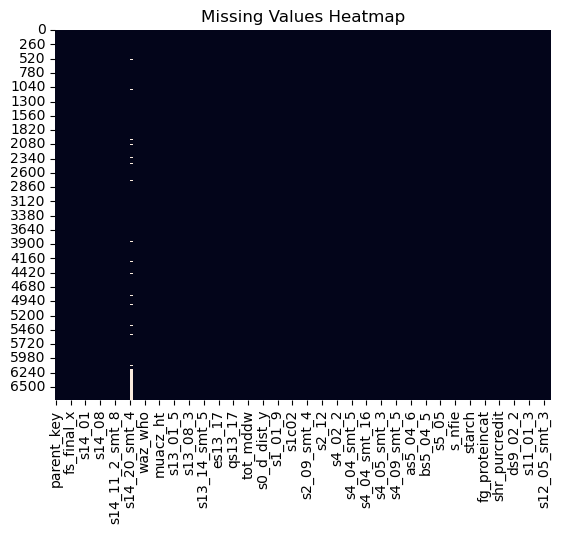

In [136]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [135]:
df['s14_20_smt_4'] = df['s14_20_smt_4'].transform(lambda x: x.fillna(x.mean()))

In [17]:
print("CM duplicates:", cm_df['parent_key'].duplicated().sum())
print("HH duplicates:", hh_df['parent_key'].duplicated().sum())
print("VL duplicates:", vl_df['key'].duplicated().sum())

CM duplicates: 1
HH duplicates: 0
VL duplicates: 0


In [18]:
hh_df = hh_df.drop_duplicates(subset='parent_key')
vl_df = vl_df.drop_duplicates(subset='key')

In [23]:
# Check matching keys
print("CM keys:", cm_df['parent_key'].nunique())
print("HH keys:", hh_df['parent_key'].nunique())
print("VL keys:", vl_df['key'].nunique())

CM keys: 11
HH keys: 0
VL keys: 987


In [28]:
hh_df.nunique().sum()

np.int64(64929)

In [ ]:
hh_df

In [ ]:
hh_meta.variable_value_labels['FS_final_lyr']

In [ ]:
hh_keys = set(hh_df['PARENT_KEY'])
cm_keys = set(cm_df['PARENT_KEY'])
len(cm_keys & hh_keys)   # intersection
len(cm_keys - hh_keys)   # keys in CM but missing from HH


""" **Why check this?** Before trusting a join between datasets, you must verify the keys actually match. Here we confirm:
 - Every single `PARENT_KEY` in the Child/Mother dataset exists in Household — a clean, safe join.
 - Not all households have children (5,067 out of 9,709) — that's expected, not a data problem.

#**The relationship between datasets:**
```
Village (987)
    └── Household (9,709)   linked via: province/district geography
            └── Child & Mother (6,736)   linked via: PARENT_KEY
"""

In [ ]:
print(hh_df.isnull().sum().sum())         # total missing cells across entire dataframe
print((hh_df.isnull().sum() > 0).sum())    # how many columns have at least one null
print((hh_df.isnull().sum() == len(hh_df)).sum())  # how many columns are 100% empty

In [ ]:
print(cm_df.isnull().sum().sum())         # total missing cells across entire dataframe
print((cm_df.isnull().sum() > 0).sum())    # how many columns have at least one null
print((cm_df.isnull().sum() == len(hh_df)).sum())  # how many columns are 100% empty

In [ ]:
print(vl_df.isnull().sum().sum())         # total missing cells across entire dataframe
print((vl_df.isnull().sum() > 0).sum())    # how many columns have at least one null
print((vl_df.isnull().sum() == len(hh_df)).sum())  # how many columns are 100% empty

In [ ]:
null_pct = (hh_df.isnull().sum() / len(hh_df) * 100).sort_values(ascending=False)

pd.cut(null_pct, bins=[-1, 0, 10, 30, 50, 80, 100])

In [ ]:
hh_df.groupby('UrbanRural')['KS12_07_3'].apply(lambda x: x.isnull().mean() * 100)

In [ ]:
hh_df.columns